### Polytope simplified use case 

In this notebook we will set up the authentication with the DestinE platform and store the API key in `~/.polytopeapirc`.  

**Note**: A comprehensive set of examples can be found in this [github repository](https://github.com/destination-earth-digital-twins/polytope-examples/tree/main/climate-dt). 



To set up the API key, we need to create a file named ```.polytopeapirc``` in the home directory (```~/.polytopeapirc```) and add the Key information with the following format: 

```
{
    "user_key" : "<user_key>"
}
```

For this purpose we will use the ```destinepyauth``` library for the authentication against DESP (Destination Earth Service Platform) services. 


In [4]:
%%capture

from destinepyauth import get_token
get_token("polytope")

After configuring teh API key, we can access the data. For simplicity we use here only the output of 'IFS-FESOM' for the year 1990 and plot the global values. 

In [27]:
import matplotlib.pyplot as plt
import healpy as hp
import earthkit.data
import xarray as xr
import numpy as np

In [ ]:
HIST_YEARS = range(1990, 2014)

if isinstance(HIST_YEARS, (int, np.integer)):
    year_str = str(HIST_YEARS)
else:
    year_str = '/'.join(str(y) for y in HIST_YEARS)

year_str

'1990/1991/1992/1993/1994/1995/1996/1997/1998/1999/2000/2001/2002/2003/2004/2005/2006/2007/2008/2009/2010/2011/2012/2013'

In [ ]:
# Earthkit cache configuration — prevents unbounded cache growth
earthkit.data.config.set("cache-policy", "temporary")
earthkit.data.config.set("maximum-cache-size", "2G")

MODELS = ['IFS-FESOM']#, 'IFS-NEMO', 'ICON']
MONTHS = "1/2/3/4/5/6/7/8/9/10/11/12"
YEARS = '1990/1991/1992/1993/1994/1995/1996/1997/1998/1999/2000/2001/2002/2003/2004/2005/2006/2007/2008/2009/2010/2011/2012/2013/2014'
YEARS=year_str
data_models = []
for model in MODELS:
    print(model)
    dict_request = {
        "class": "d1",
        "dataset": "climate-dt",
        "type": "fc",
        "expver": "0001",
        "generation": "2",
        "realization": '1',
        "activity": 'baseline',
        "experiment": 'hist',
        "model": model,
        "param": 'avg_2t',
        "levtype": "sfc",
        "resolution": 'standard',
        "stream": "clmn",
        "year": YEARS,
        "month": MONTHS,
    }

    data_models.append(
        earthkit.data.from_source(
        "polytope", 
        "destination-earth", 
        dict_request,
        address="polytope.lumi.apps.dte.destination-earth.eu", 
        stream=False
        )
    )


IFS-FESOM


In [41]:
ds = data_models[0].to_xarray(engine="cfgrib")
ds_JFM = ds.mean(dim='time')['avg_2t'].isel(heightAboveGround=0,step=0)


<Figure size 1800x500 with 0 Axes>

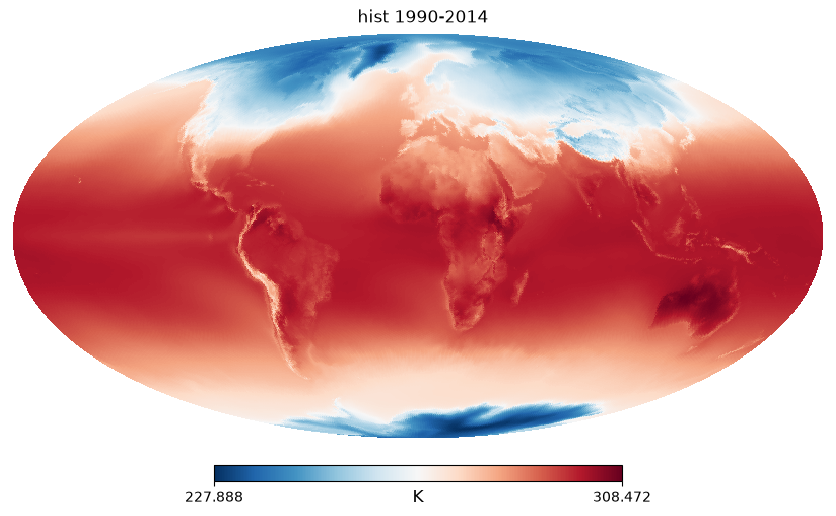

In [44]:
# Plot 2-m surface temperature
fig = plt.figure(figsize=(18, 5))
for i, model in enumerate(MODELS):
    hp.mollview(
        ds_JFM, 
        nest=True,
        flip='geo',
        cmap='RdBu_r', 
        title=
              f'  hist 1990-2014',
        unit='K',
    )